<a href="https://colab.research.google.com/github/MDRobiulhassan/Machine-Learning-Course/blob/main/Backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA

In [76]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar100

# Load CIFAR-100 dataset (fine labels by default)
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

# Check shapes
print("Training data")
print(f"- X = {x_train.shape}, y = {y_train.shape}")
print(f"- Holds {x_train.shape[0]/(x_train.shape[0]+x_test.shape[0])*100:.2f}% of the overall data\n")

print("Testing data")
print(f"- X = {x_test.shape}, y = {y_test.shape}")
print(f"- Holds {x_test.shape[0]/(x_train.shape[0]+x_test.shape[0])*100:.2f}% of the overall data")

Training data
- X = (50000, 32, 32, 3), y = (50000, 1)
- Holds 83.33% of the overall data

Testing data
- X = (10000, 32, 32, 3), y = (10000, 1)
- Holds 16.67% of the overall data


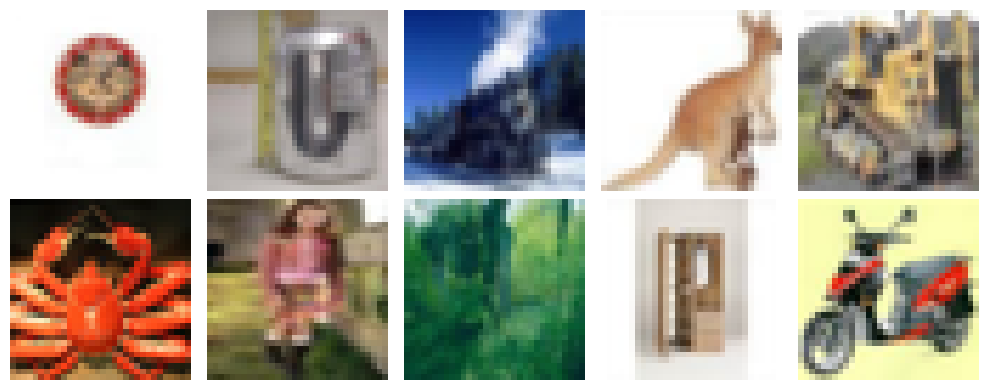

In [77]:
import matplotlib.pyplot as plt
import random

def plot_images(nb_images_to_plot, train_data):
    # Generate a list of random indices from the training data
    random_indices = random.sample(range(len(train_data)), nb_images_to_plot)

    # Compute grid size for plotting
    cols = 5
    rows = (nb_images_to_plot + cols - 1) // cols
    plt.figure(figsize=(cols*2, rows*2))

    # Plot each image using the random indices
    for i, idx in enumerate(random_indices):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(train_data[idx])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage
plot_images(10, x_train)

In [78]:
import matplotlib.pyplot as plt
import numpy as np

def plot_labels_distribution(data_labels):
    # Flatten if labels are (n,1)
    data_labels = data_labels.flatten() if len(data_labels.shape) > 1 else data_labels

    # Count occurrences of each label
    counts = np.bincount(data_labels, minlength=100)

    # Don't set any style
    # plt.style.use('seaborn-darkgrid')  # removed

    fig, ax = plt.subplots(figsize=(20,5))
    ax.bar(range(100), counts, width=0.8, align='center')
    ax.set(
        xticks=range(0,100,5),
        xlim=[-1, 100],
        xlabel='Class Label',
        ylabel='Count',
        title='Training data label distribution'
    )

    plt.show()

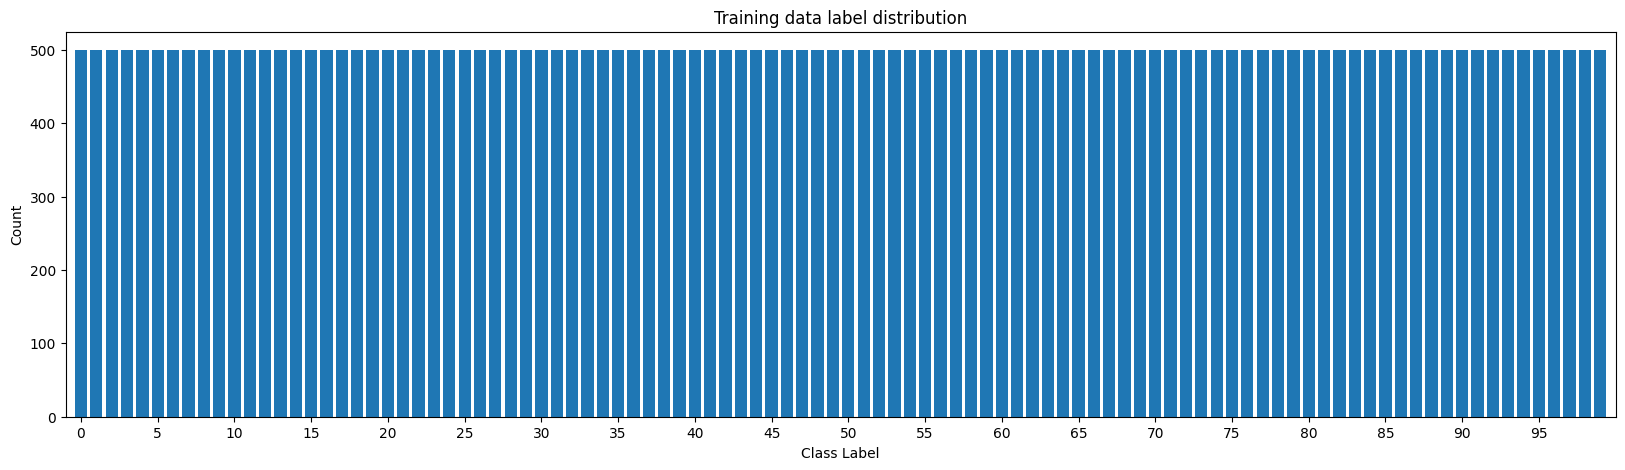

In [79]:
plot_labels_distribution(y_train)

#Data Preprocessing

In [80]:
from keras.utils import to_categorical

# 1. Preprocessing function
def preprocess_data(data, label, vector_size, grayscale_size):
    # Normalize to range 0-1
    preprocessed_images = data.reshape((data.shape[0], vector_size)).astype('float32') / grayscale_size
    # One-hot encode labels
    encoded_labels = to_categorical(label, num_classes=100)
    return preprocessed_images, encoded_labels

In [81]:
vector_size = 32 * 32 * 3  # CIFAR-100 images are 32x32x3
grayscale_size = 255

# 3. Preprocessing of the training and testing data
x_train_proc, y_train_proc = preprocess_data(x_train, y_train, vector_size, grayscale_size)
x_test_proc, y_test_proc = preprocess_data(x_test, y_test, vector_size, grayscale_size)

In [82]:
print("Training data")
print(f"- Maximum Value: {x_train_proc.max()}")
print(f"- Minimum Value: {x_train_proc.min()}\n")

print("Testing data")
print(f"- Maximum Value: {x_test_proc.max()}")
print(f"- Minimum Value: {x_test_proc.min()}\n")

Training data
- Maximum Value: 1.0
- Minimum Value: 0.0

Testing data
- Maximum Value: 1.0
- Minimum Value: 0.0



In [83]:
print("One-hot encoding sample for train labels (first 5):")
print(y_train_proc[:5])

One-hot encoding sample for train labels (first 5):
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0

In [84]:
print("\nOne-hot encoding sample for test labels (first 5):")
print(y_test_proc[:5])


One-hot encoding sample for test labels (first 5):
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0

#Network Structure

In [85]:
from keras import models, layers
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import plot_model # Corrected import path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [86]:
hidden_units = 256
nb_unique_labels = 100  # CIFAR-100 has 100 classes
vector_size = 32 * 32 * 3  # Flattened input for CIFAR-100 images

In [87]:
def define_network_architecture():
    network = models.Sequential()
    network.add(layers.Dense(vector_size, activation='relu', input_shape=(vector_size,)))  # Input layer
    network.add(layers.Dense(512, activation='relu'))  # Hidden layer
    network.add(layers.Dense(nb_unique_labels, activation='softmax'))  # Output layer
    return network

network = define_network_architecture()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


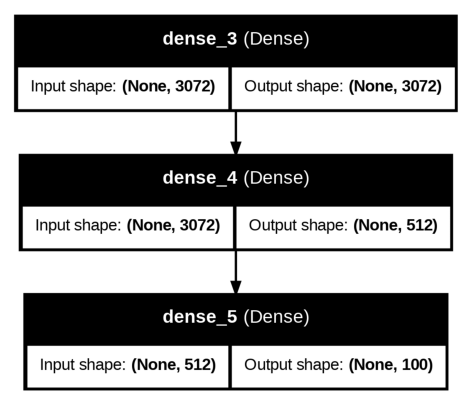

In [88]:
plot_model(network, to_file='network_architecture.png', show_shapes=True, show_layer_names=True)
plt.figure(figsize=(10, 5))
img = mpimg.imread('network_architecture.png')
plt.imshow(img)
plt.axis('off')
plt.show()

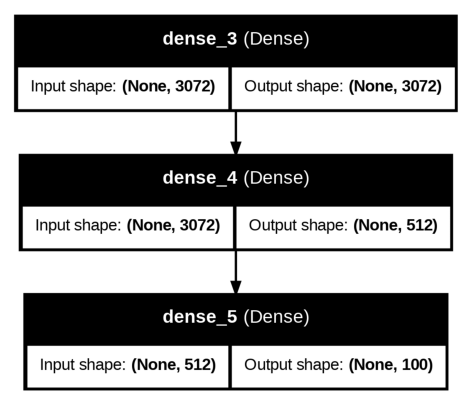

In [89]:
img = mpimg.imread('network_architecture.png')
plt.figure(figsize=(10, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

# Delta Calculation

In [90]:
# Compile the network
network.compile(
    optimizer='rmsprop',              # Optimizer for training
    loss='categorical_crossentropy',   # Appropriate loss for multi-class classification
    metrics=['accuracy']               # Metric to track during training
)

# Training

In [91]:
# Training parameters
batch_size = 256
n_epochs = 15
val_split = 0.2

In [92]:
history = network.fit(
    x_train_proc,
    y_train_proc,
    validation_split=0.2,
    epochs=n_epochs,
    batch_size=batch_size
)

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 377ms/step - accuracy: 0.0421 - loss: 4.6837 - val_accuracy: 0.0677 - val_loss: 4.0782
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 81s 367ms/step - accuracy: 0.0971 - loss: 3.9424 - val_accuracy: 0.0819 - val_loss: 4.0795
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 368ms/step - accuracy: 0.1248 - loss: 3.7643 - val_accuracy: 0.1212 - val_loss: 3.8280
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 367ms/step - accuracy: 0.1491 - loss: 3.6332 - val_accuracy: 0.1136 - val_loss: 3.8705
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 368ms/step - accuracy: 0.1698 - loss: 3.5190 - val_accuracy: 0.1480 - val_loss: 3.7084
Epoch 6/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 368ms/step - accuracy: 0.1861 - loss: 3.4203 - val_accuracy: 0.1628 - val_loss: 3.6667
Epoch 7/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 360ms/step - accuracy: 0.2014 - loss: 3.3432 - val_accuracy: 0.1561 - val_loss: 3.6027
Epoch 8/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 57s 361ms/step - accuracy: 0.2127 - loss: 3

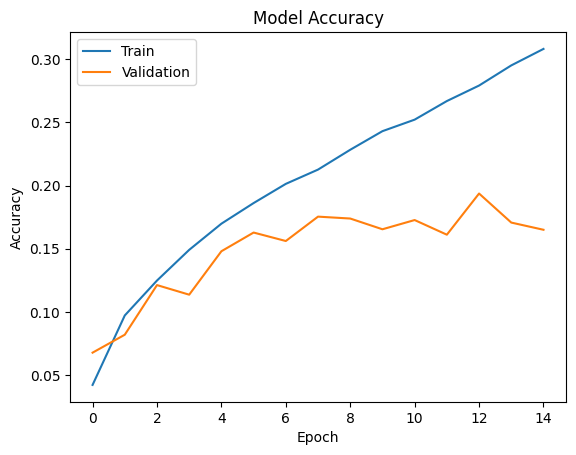

In [93]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Evaluation

In [94]:
loss, acc = network.evaluate(x_test_proc, y_test_proc, batch_size=batch_size)
print("\nTest accuracy: %.1f%%" % (100.0 * acc))

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.1657 - loss: 3.9032

Test accuracy: 16.6%
